In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the dataset as a pandas DataFrame
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target * 100_000

print(X.shape)
X.head()

(20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [4]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000


In [5]:
y.describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: MedHouseVal, dtype: float64

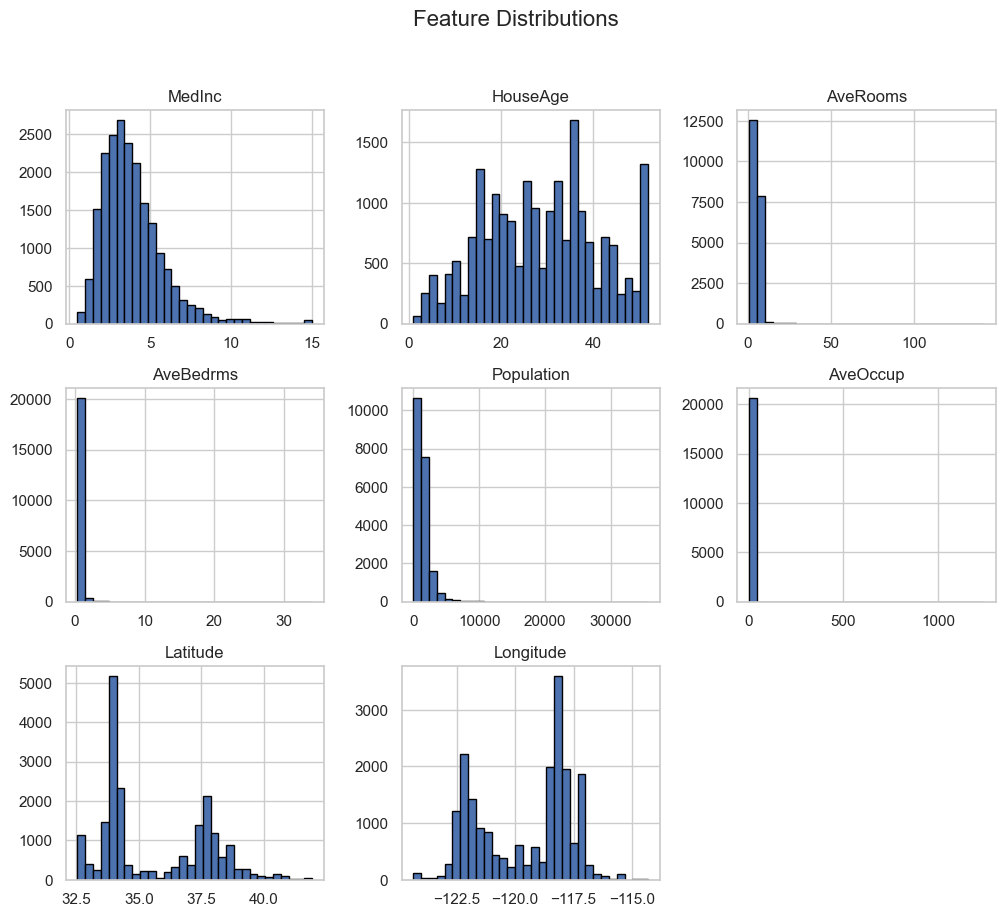

In [6]:
#Visualize the metrix features using a histogram
sns.set(style = 'whitegrid')

X.hist(figsize=(12,10), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

<Axes: >

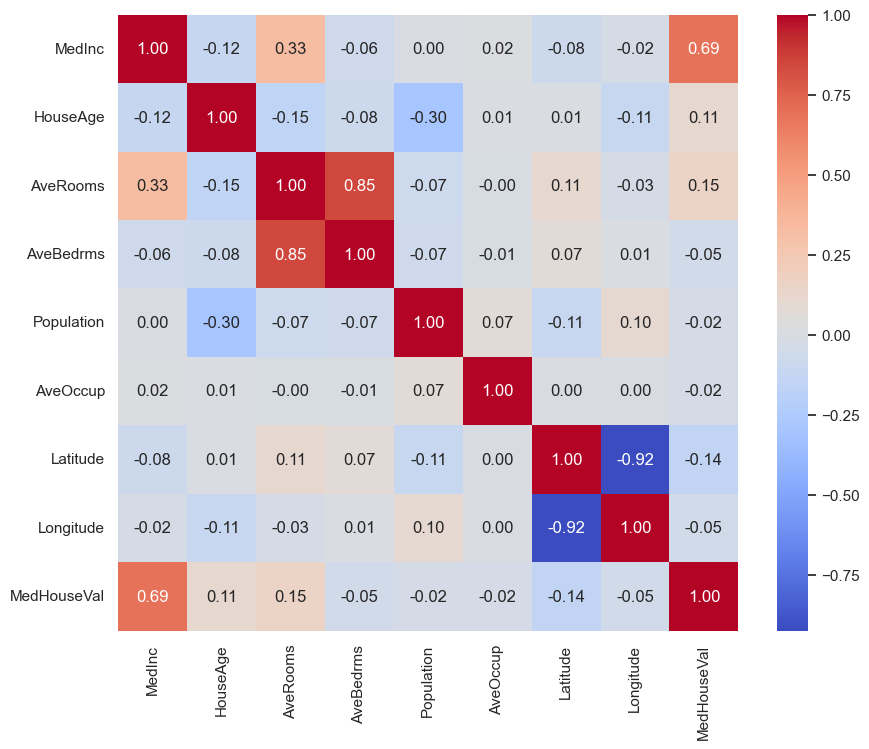

In [7]:
#Correlation Matrix

plt.figure(figsize=(10,8))
corr = X.join(y).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

In [22]:
X.head(), y[:5]

(   MedInc  HouseAge  AveBedrms  Population  AveOccup  Latitude  Longitude
 0  8.3252      41.0   1.023810       322.0  2.555556     37.88    -122.23
 1  8.3014      21.0   0.971880      2401.0  2.109842     37.86    -122.22
 2  7.2574      52.0   1.073446       496.0  2.802260     37.85    -122.24
 3  5.6431      52.0   1.073059       558.0  2.547945     37.85    -122.25
 4  3.8462      52.0   1.081081       565.0  2.181467     37.85    -122.25,
 0    452600.0
 1    358500.0
 2    352100.0
 3    341300.0
 4    342200.0
 Name: MedHouseVal, dtype: float64)

In [21]:
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: MedHouseVal, dtype: float64

In [10]:
### Train de model ###
X = X.drop(['AveRooms'], axis =1)

In [34]:
# From sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [35]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
X_test.head(1), y_test.head(1)

(       MedInc  HouseAge  AveBedrms  Population  AveOccup  Latitude  Longitude
 20046  1.6812      25.0   1.022284      1392.0  3.877437     36.06    -119.01,
 20046    47700.0
 Name: MedHouseVal, dtype: float64)

In [43]:
print("Train R² score:", model.score(X_train, y_train))
print("Test R² score:", model.score(X_test, y_test))

Train R² score: 0.601190030899923
Test R² score: 0.5957806761287978


In [44]:
# Simple Linear Predition of the MedHouseVal in 100ks

y_pred = model.predict(X_test)

#Take a quick look at the first few predictions
y_pred[:10]

array([ 71756.95197977, 177024.25670801, 252931.97637156, 287226.01247174,
       271032.70818148, 199477.48903259, 267841.58853562, 217029.89575646,
       253955.29450536, 387184.18168098])

In [45]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,47700.0,71756.951980
1,45800.0,177024.256708
2,500001.0,252931.976372
3,218600.0,287226.012472
4,278000.0,271032.708181
5,158700.0,199477.489033
6,198200.0,267841.588536
7,157500.0,217029.895756
8,340000.0,253955.294505
9,446600.0,387184.181681


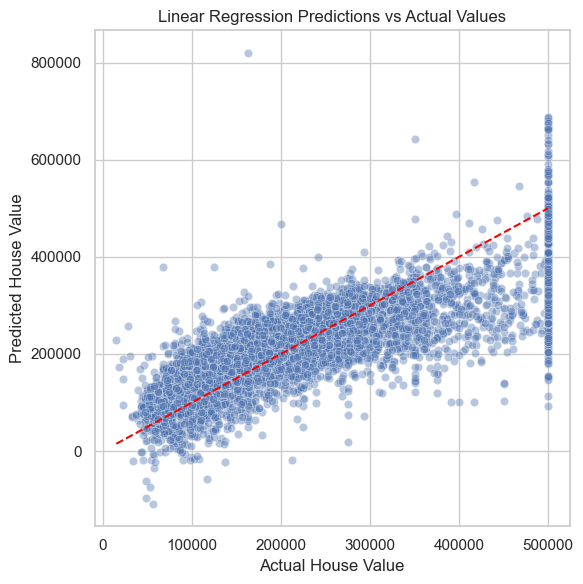

In [46]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Linear Regression Predictions vs Actual Values")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")
plt.tight_layout()
plt.show()

In [47]:
# Diagnose your model
 
mae = mean_absolute_error(y_test, y_pred)   # MAE is the average absolute error
mse = mean_squared_error(y_test, y_pred)    # MSE is mean squared error
rmse = np.sqrt(mse)                         # is it larger because of the unit scale?
r2 = r2_score(y_test, y_pred)               # R² shows how much variance the model explains - model captures 59.6% of the pattern

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE:{rmse:.3f}")
print(f"R2:  {r2:.3f}")
 

MAE: 53490.222
MSE: 5305540749.344
RMSE:72839.143
R2:  0.596


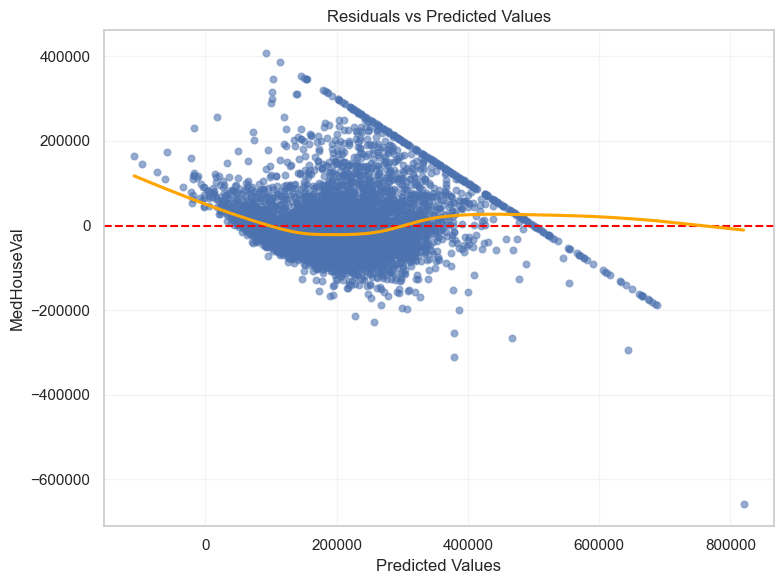

In [48]:
# residuals and pltting them
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.grid(alpha=0.2)
plt.tight_layout()
sns.regplot(x=y_pred, y=residuals, lowess=True, scatter_kws={'alpha':0.3, 's':20}, line_kws={'color':'orange'})
plt.show()


In [50]:
residuals.describe()

count      6192.000000
mean       -239.391242
std       72844.631980
min     -657449.982327
25%      -47463.980165
50%      -13205.693410
75%       30880.304524
max      408197.767491
Name: MedHouseVal, dtype: float64

In [51]:
residual_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": residuals
})

residual_df.head()

,Actual,Predicted,Residual
20046,47700.0,71756.951980,-24056.951980
3024,45800.0,177024.256708,-131224.256708
15663,500001.0,252931.976372,247069.023628
20484,218600.0,287226.012472,-68626.012472
9814,278000.0,271032.708181,6967.291819


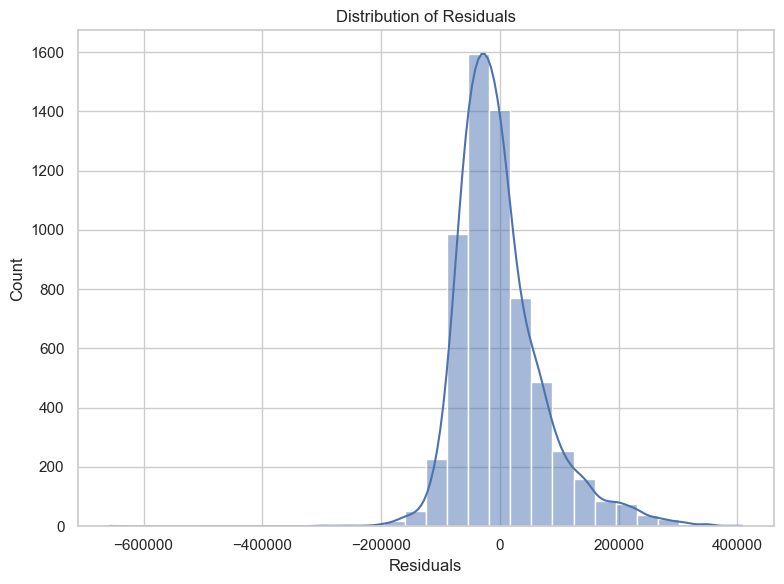

In [17]:
# Distribution of residuals - general will be a normal distribution

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.tight_layout()
plt.show()

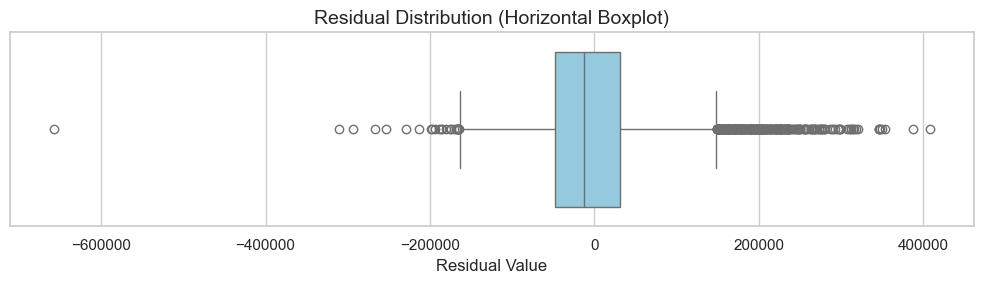

In [18]:
plt.figure(figsize=(10,3))
sns.boxplot(x=residuals, color='skyblue')

plt.title("Residual Distribution (Horizontal Boxplot)", fontsize=14)
plt.xlabel("Residual Value", fontsize=12)
plt.yticks([]) # removes the empty categorical axis
plt.tight_layout()
plt.show()